### Вторая часть

Мы выбрали Бизнес банковский маркетинг в качестве предметной области и анализ факторов, связанных с готовносью клиентов открыть срочный депозит в качестве задачи. 

Банковский маркетинг значим для бизнеса, потому что банки заинтересованы в повышении эффективности маркетинговых кампаний, точнее выбирать клиентов для обзвонов, снижать затраты на неэффективных клиентов и увеличивать долю клиентов, согласившихся на вклад. 

Для анализа был выбран датасет [bank-full](https://archive.ics.uci.edu/dataset/222/bank+marketing), данные связаны с прямыми маркетинговыми кампаниями (телефонными звонками) португальского банка.

### Описание данных

Датасет содержит:
- 45 211 записей
- 17 признаков, включая целевую переменную `y`

Целевая переменная:
- `y` - оформил ли клиент срочный депозит
  - `yes` - клиент оформил депозит
  - `no` - клиент не оформил депозит

### Описание признаков

- `age` - возраст клиента. *Тип:* `Числовой признак`. 
- `job` - тип занятости клиента. *Тип:* `Категориальный признак`. 
- `marital` - семейное положение клиента. *Тип:* `Категориальный признак`.
- `education` - уровень образования клиента. *Тип:* `Категориальный признак`.
- `default` - есть ли у клиента просроченный кредит. *Тип:* `Бинарный признак`.
- `balance` - средний годовой баланс клиента в евро. *Тип:* `Числовой признак`.
- `housing` - есть ли у клиента ипотечный или жилищный кредит. *Тип:* `Бинарный признак`.
- `loan` - есть ли у клиента потребительский кредит. *Тип:* `Бинарный признак`.
- `contact` - тип коммуникации с клиентом. *Тип:* `Категориальный признак`.
- `day` - день месяца, когда был последний контакт с клиентом. *Тип:* `Числовой признак`.
- `month` - месяц последнего контакта с клиентом. *Тип:* `Категориальный признак`.
- `duration` - длительность последнего контакта с клиентом в секундах. *Тип:* `Числовой признак`
- `campaign` - количество контактов с клиентом в рамках текущей кампании, включая последний контакт. *Тип:* `Числовой признак`.
- `pdays` - количество дней, прошедших с момента последнего контакта с клиентом в предыдущей кампании. *Тип:* `Числовой признак`.
- `previous` - количество контактов с клиентом до текущей кампании. *Тип:* `Числовой признак`.
- `poutcome` - результат предыдущей маркетинговой кампании. *Тип:* `Категориальный признак`.
- `y` - Целевая переменная. Оформил ли клиент срочный банковский вклад. *Тип:* `Бинарный признак`.

### Первый блок EDA

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

palette = ["#1f2d3a", "#0f766e"]


def pick_color(n):
    return [palette[i % len(palette)] for i in range(len(n))]

In [66]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [67]:
df.shape

(45211, 17)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [69]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [70]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [71]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [74]:
cols = df.select_dtypes(include="object").columns
for i in cols:
    print(df[i].value_counts())
    print("\n")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failure 

#### Выводы по первому блоку EDA

По итогам первичного погружения в данные мы имеем в датасете 45211 записей и 17 признаков, включая целевую переменную. Дубликатов и явных пропусков нет, но в некоторых признаках встречаются значения `unknown`, что не дает нам однозначной и точной информации по клиенту. 

Целевая переменная `y` хранит информацию о том, оформил ли клиент срочный вклад или нет. Далее будем анализировать как доля положительных ответов меняется в разных группах клиентов.

### Второй блок EDA

In [75]:
unk = df.select_dtypes(include="object").columns
s = []
for i in unk:
    c = sum(df[i] == "unknown")
    amount = c / len(df) * 100
    if c > 0:
        s.append([i, c, round(amount, 2)])
out = pd.DataFrame(s, columns=["column", "unknown_amount", "unknown_amount_percent"])
out

,column,unknown_amount,unknown_amount_percent
0,job,288,0.64
1,education,1857,4.11
2,contact,13020,28.80
3,poutcome,36959,81.75


Значения `unknown` не удаляем и не заменяем, так как оно само по себе может нести информацию, так, в признаке `poutcome` значение `poutcome = unknown` может означать отсутствие результата по прошлой кампании или отсутствие предыдущей связи с клиентом. Поэтому в EDA будем рассматривать это значение как отдельную категорию. 

In [76]:
df["marital"].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [77]:
c = df["y"].value_counts()
c

y
no     39922
yes     5289
Name: count, dtype: int64

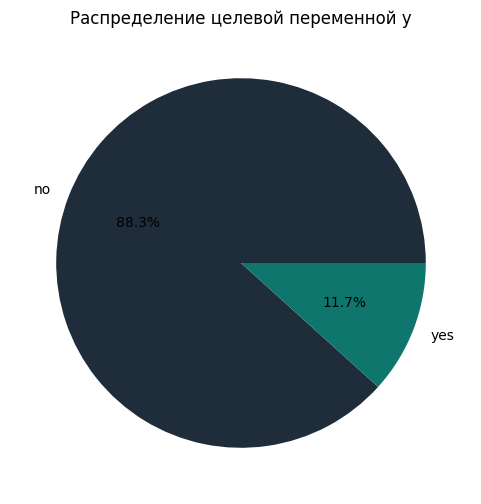

In [78]:
c = df["y"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(c.values, labels=c.index, autopct="%1.1f%%", colors=pick_color(c))
plt.title("Распределение целевой переменной y")
plt.show()

Целевая переменная является несбалансированной, так как доля клиентов, открывших срочный депозит, составляет примерно 11.7%. Поэтому в анализе фокус будет не на количество клиентов с `y = yes`, а на конверсии внутри групп. Также для групп с высокой конверсией необходимо учитывать размер группы, так как высокая доля положительных исходов в небольшой группе может быть не такой устойчивой и показательной, поэтому при интерпретации будет учитываться размер групп клиентов.

Закодируем значения в целевой переменной как `yes` : 1, `no`: 0.

In [79]:
df["y_new"] = df["y"].map({"yes": 1, "no": 0})
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_new
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0


Рассмотрим признаки, которые описывают клиента как человека: `age`, `job`, `marital`, `education`. Интересует, конечно же, как меняется доля окрывших вклад в разных группах. 

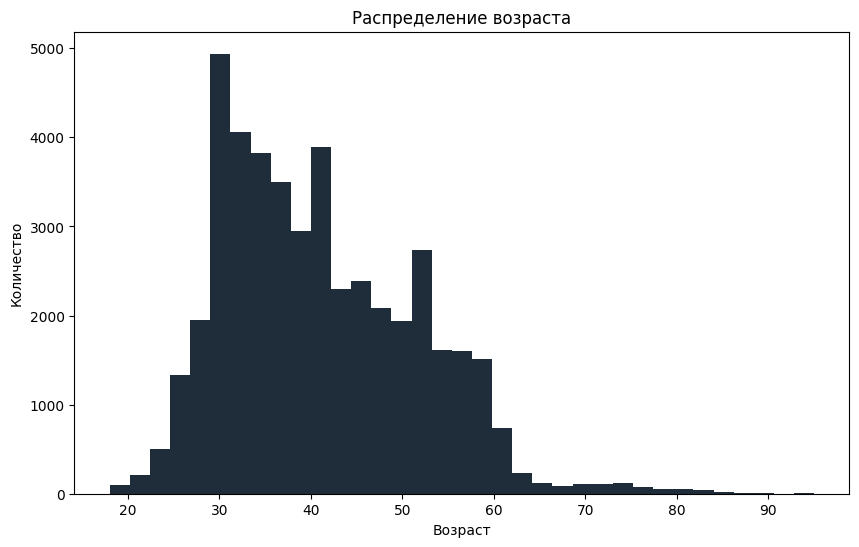

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["age"], bins=35, color=palette[0])
plt.title("Распределение возраста")
plt.xlabel("Возраст")
plt.ylabel("Количество");

Видим, что в данных преоладает средняя возрастная группа 30-40 лет 

/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/3802585635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="age", palette=palette)


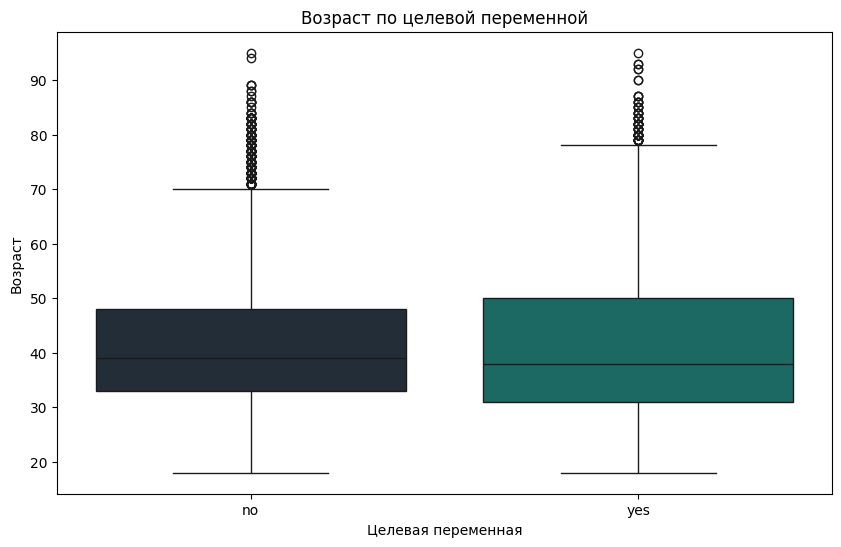

In [81]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="y", y="age", palette=palette)
plt.title("Возраст по целевой переменной")
plt.xlabel("Целевая переменная")
plt.ylabel("Возраст");

По графику boxplot видим, что распределения возраста для клиентов, открывших и не открывших вклад в целом похожи. Медианы находятся примерно на одном уровне, межквартильные интоервалы тоже примерно одинаковые, что скорее говорит о том, что возраст не сильно влияет на решение клиента об открытии вклада. Однако у `yes` верхний ус выше, чем у `no`, что говорит о наличии более возрастных клиентов среди тех, кто открывал вклад. Далее посмотрим на распреедение возрастных групп. 

In [82]:
df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

In [83]:
df["age_groups"] = pd.cut(
    df["age"],
    bins=[17, 25, 30, 45, 60, 70, 95],
    labels=["18-25", "25-30", "30-45", "45-60", "60-70", "70-95"],
)

In [84]:
conv = df.groupby("age_groups")["y_new"].mean()
conv

/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/266792143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv = df.groupby("age_groups")["y_new"].mean()


age_groups
18-25    0.239521
25-30    0.144889
30-45    0.098808
45-60    0.097813
60-70    0.405136
70-95    0.447639
Name: y_new, dtype: float64

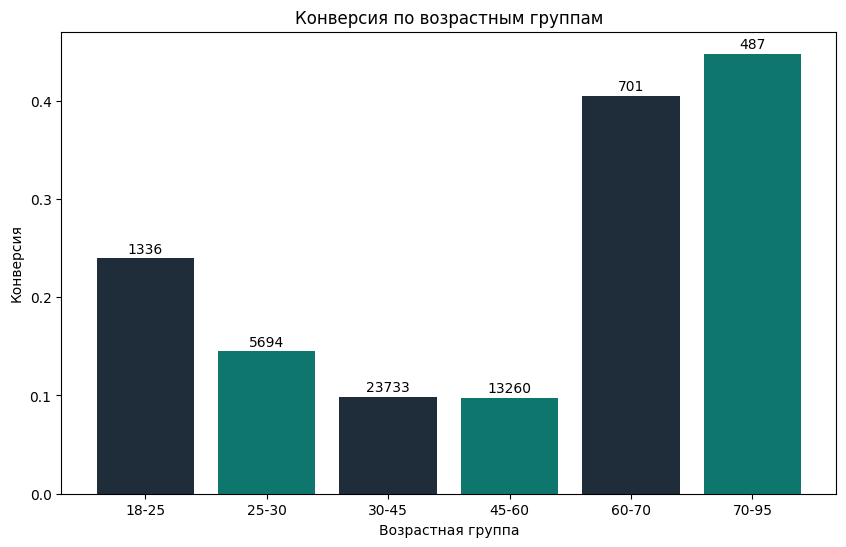

In [85]:
age_counts = df["age_groups"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(conv.index, conv.values, color=pick_color(conv))
plt.title("Конверсия по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Конверсия")

for i in range(len(conv)):
    plt.text(i, conv.values[i] + 0.005, age_counts.values[i], ha="center")

Конверсия различается между возрастными группами. Самая низкая конверсия среди клиентов `45-60` и `30-45`, клиенты в этой группе имеют конверсию около 10%, более высокая конверсия замечена у молодых клиентов `18-25` - 23%, а у клиентов 60+ конверсия от 40%. Однако наблюдений по пожилым людям значительно меньше.

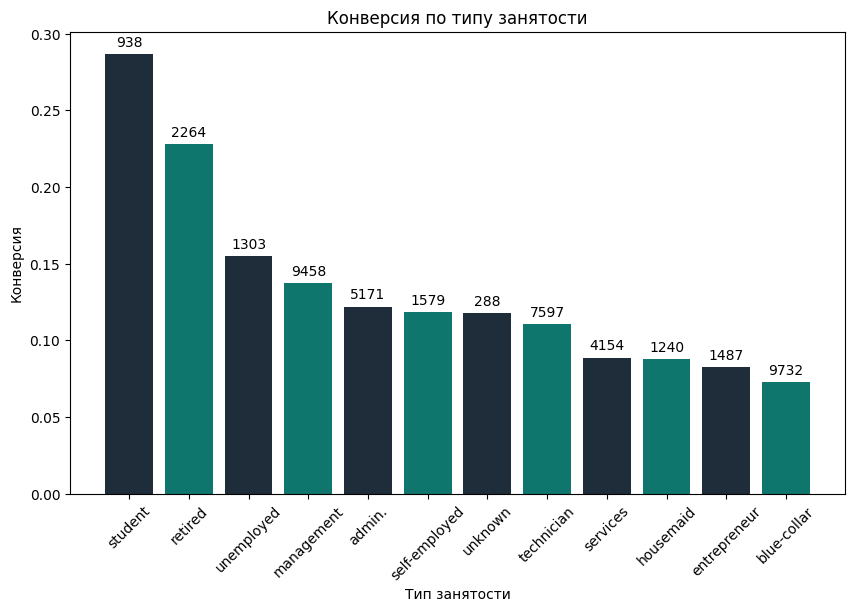

In [86]:
job_conv = df.groupby("job")["y_new"].mean().sort_values(ascending=False)
job_counts = df["job"].value_counts()[job_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(job_conv.index, job_conv.values, color=pick_color(job_conv))
plt.title("Конверсия по типу занятости")
plt.xlabel("Тип занятости")
plt.ylabel("Конверсия")
plt.xticks(rotation=45)

for i in range(len(job_conv)):
    plt.text(i, job_conv.values[i] + 0.005, job_counts.values[i], ha="center")
plt.show()

Конверсия значительно различается среди клиентов с разным типом занятости, наибольщую конвесию показывают студенты и песионеры. Это может быть связано с тем, что данные группы клиентов более заинтеересованы в сбереженияхю. Самая низкая конверсия наблюдается у `services`, `housemade`, `entrepreneur`, `blue-collar`. Группа `blue colar` самая многочисленная из всех и при этом самая неэффективная.

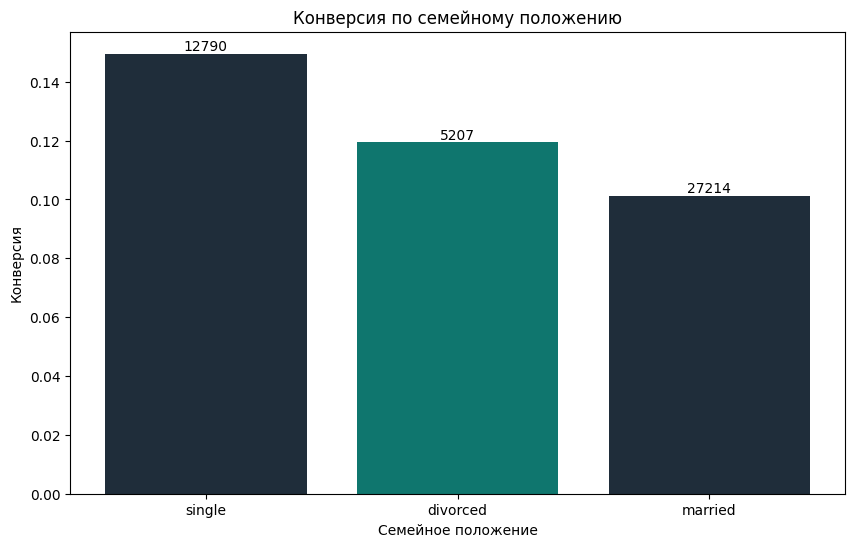

In [87]:
marital_conv = df.groupby("marital")["y_new"].mean().sort_values(ascending=False)
marital_counts = df["marital"].value_counts()[marital_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(marital_conv.index, marital_conv.values, color=pick_color(marital_conv))
plt.title("Конверсия по семейному положению")
plt.xlabel("Семейное положение")
plt.ylabel("Конверсия")

for i in range(len(marital_conv)):
    plt.text(i, marital_conv.values[i] + 0.001, marital_counts.values[i], ha="center")
plt.show()

Клиенты со статусом `single` имеют самую высокую конверсию, далее идут `divorced`, и самое низкое значение конверсии у `married`(самая большая группа)

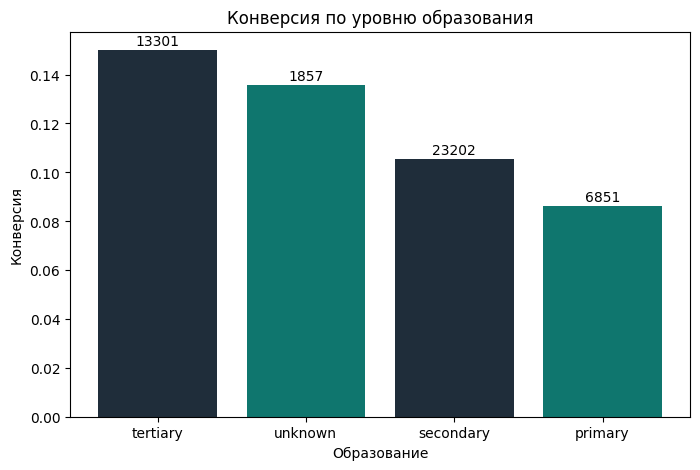

In [88]:
education_conv = df.groupby("education")["y_new"].mean().sort_values(ascending=False)
education_counts = df["education"].value_counts()[education_conv.index]
plt.figure(figsize=(8, 5))
plt.bar(education_conv.index, education_conv.values, color=pick_color(education_conv))
plt.title("Конверсия по уровню образования")
plt.xlabel("Образование")
plt.ylabel("Конверсия")

for i in range(len(education_conv)):
    plt.text(
        i, education_conv.values[i] + 0.002, education_counts.values[i], ha="center"
    )
plt.show()

Конверсия различается в зависимости от уровня образования. Самое большое число окрывших депозит находится среди клиентов с высшим образованием, а самая низкая у клиентов с начальным образованием. Группа `secondary` является самой большой, но ее конверсия ниже, чем у `tertiary`.


Из анализа профилей клиентов можно сказать, что конверсия отличается в зависимости от принадлежности к разным группам. Более высокую конверсию показывают молодые и пожилые клиенты, клиенты с семейным статусом `single` и высшим образованием. По типу занятости также лидируют `student` и `retired`. 

### Третий блок EDA

In [89]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_new,age_groups
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,45-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,30-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,30-45
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,45-60
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,30-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1,45-60
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1,70-95
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1,70-95
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0,45-60


Здесь будем рассматривать `default`, `balance`, `housing`, `loan`. Необходимо пончять, связаны ли финансовые характеристики клиентов с вероятностью открытия вклада. 

In [90]:
df["balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

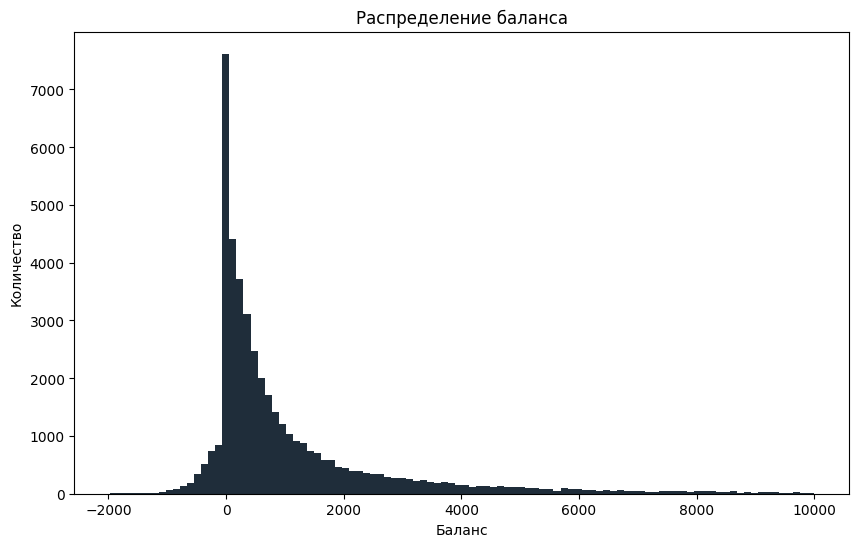

In [91]:
plt.figure(figsize=(10, 6))
plt.hist(
    df[(df["balance"] >= -2000) & (df["balance"] <= 10000)]["balance"],
    bins=100,
    color=palette[0],
)
plt.xlabel("Баланс")
plt.ylabel("Количество")
plt.title("Распределение баланса");

/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/227888797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered, x="y", y="balance", palette=palette)


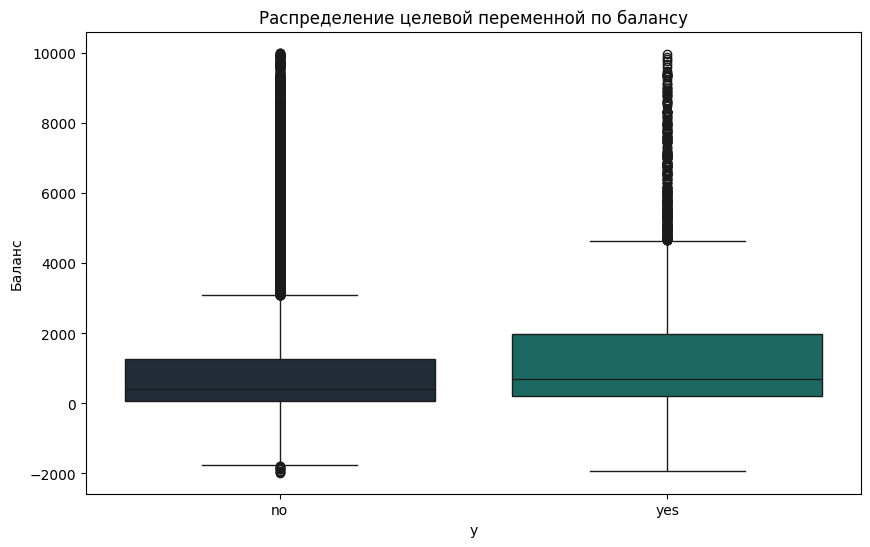

In [92]:
filtered = df[(df["balance"] >= -2000) & (df["balance"] <= 10000)]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered, x="y", y="balance", palette=palette)
plt.xlabel("y")
plt.ylabel("Баланс")
plt.title("Распределение целевой переменной по балансу");

In [93]:
df.groupby("y")["balance"].agg(["count", "mean", "median"])

,count,mean,median
y,,,
no,39922,1303.714969,417.0
yes,5289,1804.267915,733.0


Клиенты, открывшие депозит, в среденем имеют большее количестов денег на балансе. Это может быть связано со склонностью размещать деньги на вклад, имея достаточный запас средств. 

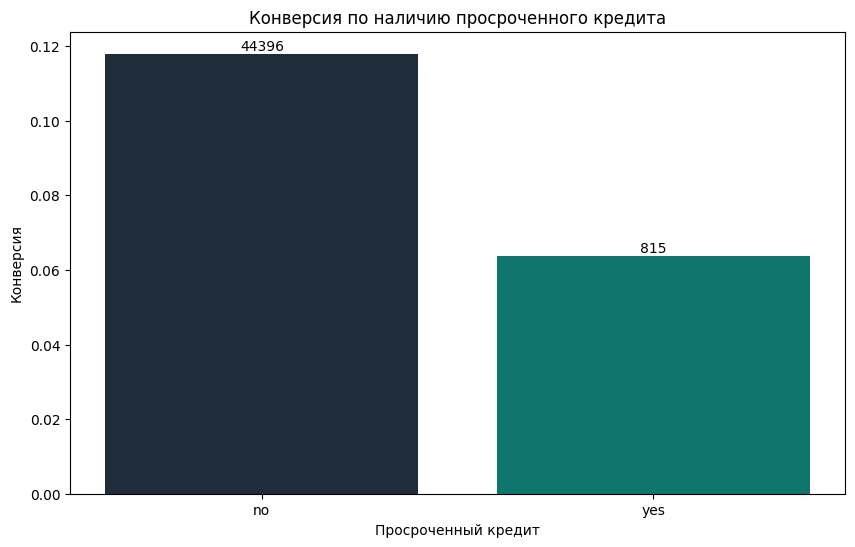

In [94]:
default_conv = df.groupby("default")["y_new"].mean().sort_values(ascending=False)
default_counts = df["default"].value_counts()[default_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(default_conv.index, default_conv.values, color=pick_color(default_conv))
plt.title("Конверсия по наличию просроченного кредита")
plt.xlabel("Просроченный кредит")
plt.ylabel("Конверсия")

for i in range(len(default_conv)):
    plt.text(i, default_conv.values[i] + 0.001, default_counts.values[i], ha="center")

plt.show()

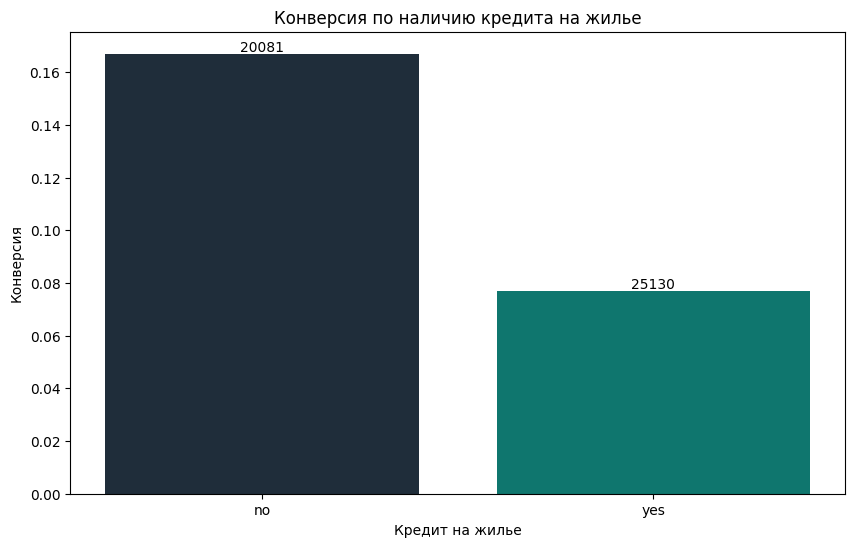

In [95]:
housing_conv = df.groupby("housing")["y_new"].mean().sort_values(ascending=False)
housing_counts = df["housing"].value_counts()[housing_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(housing_conv.index, housing_conv.values, color=pick_color(housing_conv))
plt.title("Конверсия по наличию кредита на жилье")
plt.xlabel("Кредит на жилье")
plt.ylabel("Конверсия")

for i in range(len(housing_conv)):
    plt.text(i, housing_conv.values[i] + 0.001, housing_counts.values[i], ha="center")
plt.show()

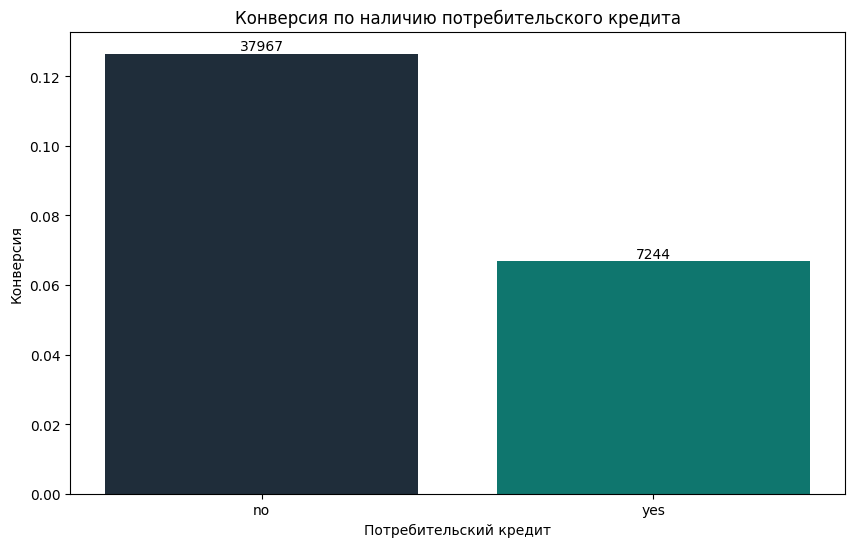

In [96]:
loan_conv = df.groupby("loan")["y_new"].mean().sort_values(ascending=False)
loan_counts = df["loan"].value_counts()[loan_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(loan_conv.index, loan_conv.values, color=pick_color(loan_conv))
plt.title("Конверсия по наличию потребительского кредита")
plt.xlabel("Потребительский кредит")
plt.ylabel("Конверсия")

for i in range(len(loan_conv)):
    plt.text(i, loan_conv.values[i] + 0.001, loan_counts.values[i], ha="center")
plt.show()

Финансовые показатели клиентов связаны с различиями в конверсии. Так, клиенты с низкой кредитной нагрузкой имеют в среденм конверсию в два раза больше, чем клиенты, которые давнной нагрузкой обременены. Также клиенты, согласившиеся на депозит имеют более высокий средний и медианный баланс. Финансовое состояние клиента может использоваться для приоритизации в маркетинговых компаниях. 

### Четвертый блок EDA 

Здесь рассмотрим признаки, связанные с коммуникацией `contact`, `day`, `month`, `duration`, `campaign`

`duration` становится известен только после контакта, поэтому его лучше использовать для анализа качества взаимодействия, а не для критерия отбора клиентов.

In [97]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_new,age_groups
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,45-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,30-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,30-45
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,45-60
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,30-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1,45-60
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1,70-95
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1,70-95
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0,45-60


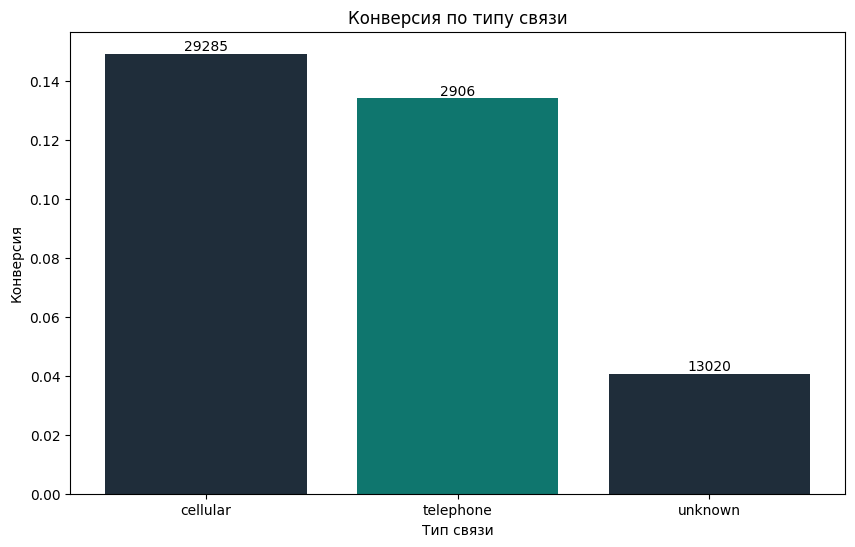

In [98]:
contact_conv = df.groupby("contact")["y_new"].mean().sort_values(ascending=False)
contact_counts = df["contact"].value_counts()[contact_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(contact_conv.index, contact_conv.values, color=pick_color(contact_conv))
plt.title("Конверсия по типу связи")
plt.xlabel("Тип связи")
plt.ylabel("Конверсия")

for i in range(len(contact_conv)):
    plt.text(i, contact_conv.values[i] + 0.001, contact_counts.values[i], ha="center")
plt.show()

Клиенты, с которыми связь выстраивалась с помощью `cellular` или `telephone`, чаще открывали срочный депозит, чем клиенты с `unknown`.

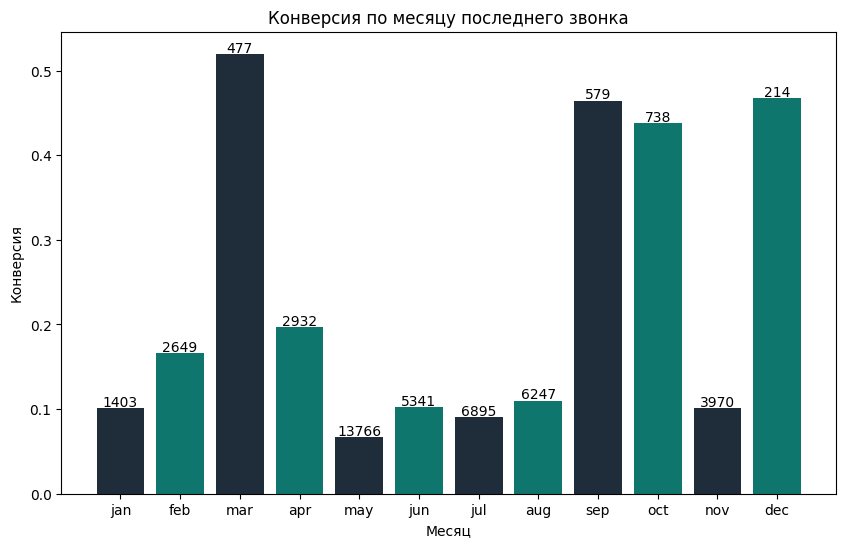

In [99]:
months = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

month_conv = df.groupby("month")["y_new"].mean().reindex(months)
month_counts = df["month"].value_counts()[month_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(month_conv.index, month_conv.values, color=pick_color(month_conv))
plt.title("Конверсия по месяцу последнего звонка")
plt.xlabel("Месяц")
plt.ylabel("Конверсия")

for i in range(len(month_conv)):
    plt.text(i, month_conv.values[i] + 0.002, month_counts.values[i], ha="center")
plt.show()

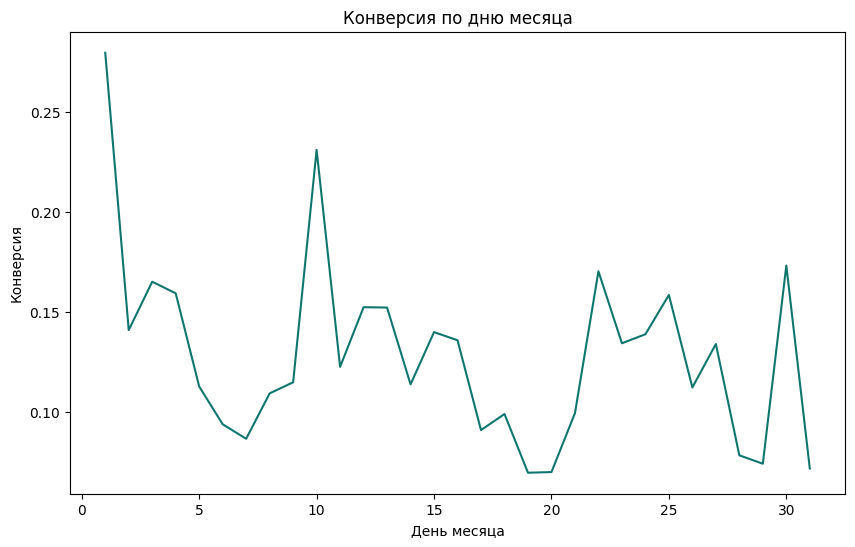

In [100]:
day_conv = df.groupby("day")["y_new"].mean()
plt.figure(figsize=(10, 6))
plt.plot(day_conv.index, day_conv.values, color=palette[1])
plt.title("Конверсия по дню месяца")
plt.xlabel("День месяца")
plt.ylabel("Конверсия");

In [101]:
df.groupby("y")["duration"].agg(["count", "mean", "median"])

,count,mean,median
y,,,
no,39922,221.182806,164.0
yes,5289,537.294574,426.0


В целом успешные контакты длятся дольше, но время мы узнаем после совершения звонка, поэтому для выбора клиентов до контакта использование данног опризнака недопустимо. 

In [102]:
df["campaign"].describe()

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

In [103]:
df["campaign"].value_counts().sort_values()

campaign
44        1
46        1
58        1
39        1
63        1
51        1
55        1
41        2
50        2
37        2
38        3
43        3
35        4
36        4
34        5
33        6
30        8
32        9
27       10
31       12
26       13
28       16
29       16
24       20
23       22
25       22
22       23
21       35
20       43
19       44
18       51
17       69
16       79
15       84
14       93
13      133
12      155
11      201
10      266
9       327
8       540
7       735
6      1291
5      1764
4      3522
3      5521
2     12505
1     17544
Name: count, dtype: int64

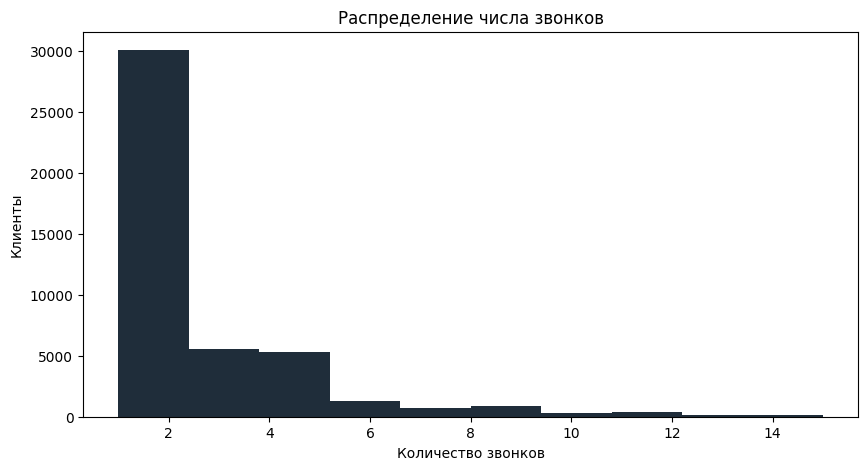

In [104]:
plt.figure(figsize=(10, 5))
plt.hist(df[df["campaign"] <= 15]["campaign"], bins=10, color=palette[0])
plt.xlabel("Количество звонков")
plt.ylabel("Клиенты")
plt.title("Распределение числа звонков");

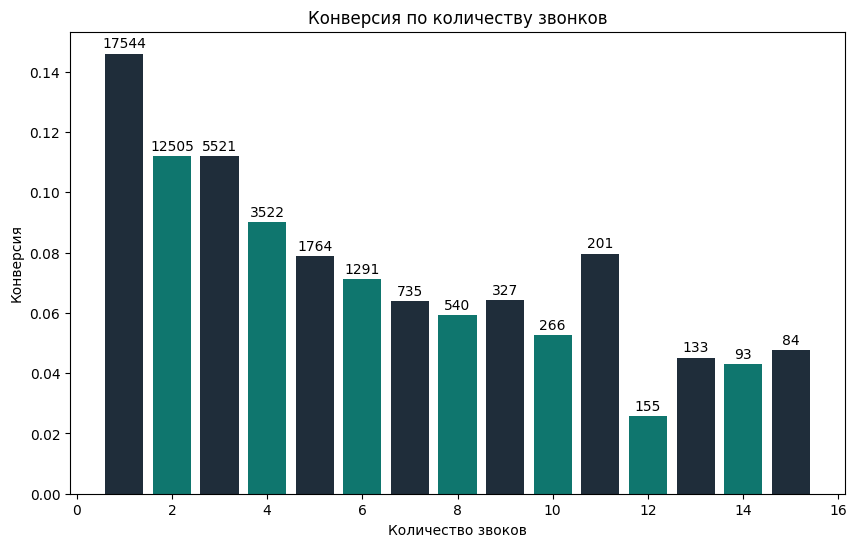

In [105]:
campaign_conv = df[df["campaign"] <= 15].groupby("campaign")["y_new"].mean()
campaign_counts = df[df["campaign"] <= 15]["campaign"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(campaign_conv.index, campaign_conv.values, color=pick_color(campaign_conv))
plt.title("Конверсия по количеству звонков")
plt.xlabel("Количество звоков")
plt.ylabel("Конверсия")

for i in range(len(campaign_conv)):
    plt.text(
        i + 1, campaign_conv.values[i] + 0.002, campaign_counts.values[i], ha="center"
    )
plt.show()

При увеличении числа звонков в рассматриваемой кампании можно заметить, что конверсия не растет, а скорее падает, что может говорить о том, что если клиент не заинтересовался после первых контактов, то дальнейшие звонки могут дать меньшую отдачу. Но нельзя утверждать, что больше звонков - меньше вероятность открытия вклада. 

Конверсия выше у клиентов, с которыми связь выстраивалась с помощью `cellular` или `telephone` и значительно ниже у тех, у кого канал связи не был зафиксирован явно. Есть различия по месяцам контакта, что может говорить о сезонности обзвона клиентов.

### Пятый блок EDA

Здесь рассмотрим признаки, связанные с предыдущими кампаниями `pdays`, `previous`, `poutcome`

In [106]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_new,age_groups
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,45-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,30-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,30-45
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,45-60
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,30-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1,45-60
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1,70-95
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1,70-95
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0,45-60


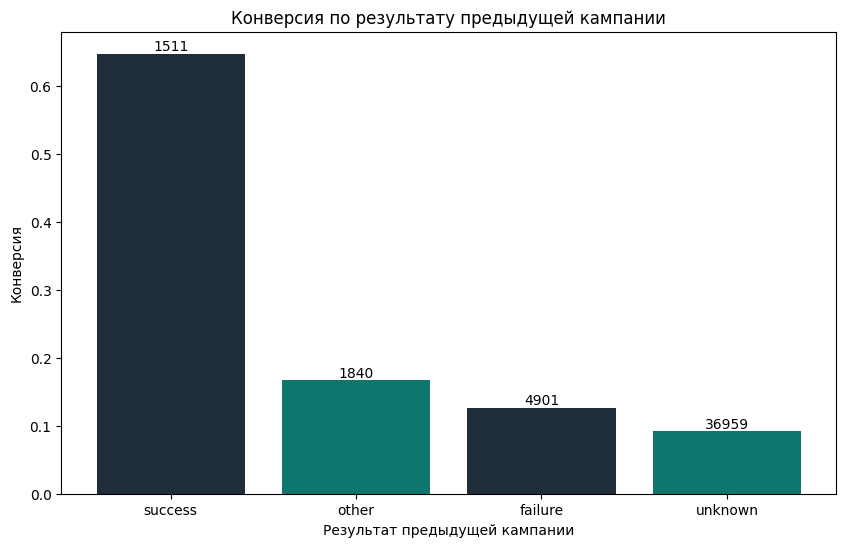

In [107]:
poutcome_conv = df.groupby("poutcome")["y_new"].mean().sort_values(ascending=False)
poutcome_counts = df["poutcome"].value_counts()[poutcome_conv.index]
plt.figure(figsize=(10, 6))
plt.bar(poutcome_conv.index, poutcome_conv.values, color=pick_color(poutcome_conv))
plt.title("Конверсия по результату предыдущей кампании")
plt.xlabel("Результат предыдущей кампании")
plt.ylabel("Конверсия")

for i in range(len(poutcome_conv)):
    plt.text(i, poutcome_conv.values[i] + 0.005, poutcome_counts.values[i], ha="center")
plt.show()

In [108]:
df["pdays"].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

In [109]:
print(f"Количество клиентов без предыдущего контакта: {sum(df["pdays"] == -1)}")
print(f"Доля клиентов без предыдущего контакта: {sum(df["pdays"] == -1) / len(df):.2f}")

Количество клиентов без предыдущего контакта: 36954
Доля клиентов без предыдущего контакта: 0.82


In [110]:
df["contacted"] = df["pdays"] != -1
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_new,age_groups,contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,45-60,False
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,30-45,False
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,30-45,False
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,45-60,False
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,30-45,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1,45-60,False
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1,70-95,False
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1,70-95,True
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0,45-60,False


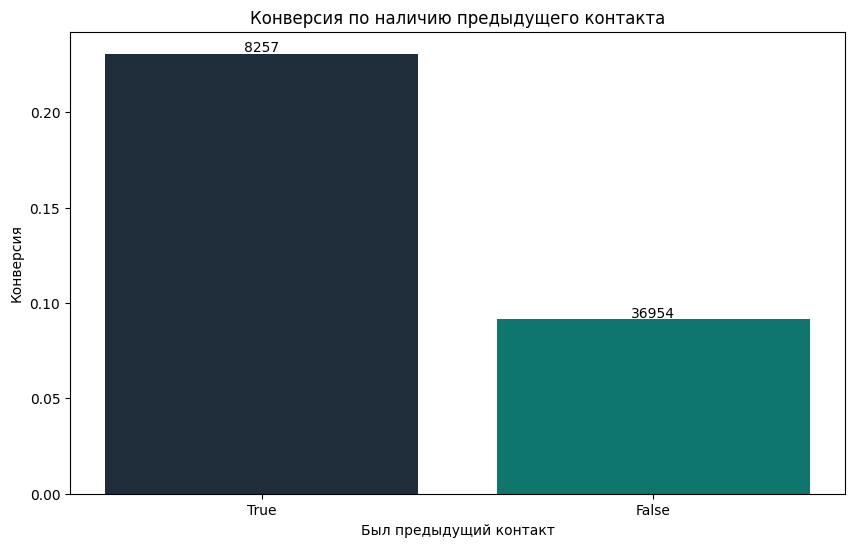

In [111]:
contacted_conv = df.groupby("contacted")["y_new"].mean().sort_values(ascending=False)
contacted_counts = (
    df.groupby("contacted")["y_new"].count().reindex(contacted_conv.index)
)
plt.figure(figsize=(10, 6))
plt.bar(
    contacted_conv.index.astype(str),
    contacted_conv.values,
    color=pick_color(contacted_conv),
)
plt.title("Конверсия по наличию предыдущего контакта")
plt.xlabel("Был предыдущий контакт")
plt.ylabel("Конверсия")

for i in range(len(contacted_conv)):
    plt.text(
        i, contacted_conv.values[i] + 0.001, contacted_counts.values[i], ha="center"
    )
plt.show()

Клиенты, у которых предыдущая кампания завершилась успехом, значительно чаще открывают вклад. Также клиенты, с которыми банк связывалдся ранее, имеют более высокую конверсию. 

### Основные наблюдения по EDA
 - Конверсия различается по возрасту, типу занятости, семейному положению и образованию
 - Клиенты с более высоким балансом чаще открывают срочный депозит
 - Наличие действующих кредитов может снижать готовность клиента открыть вклад
 - При увеличении числа контактов с клиентом конверсия не демонстрирует рост, а скорее даже снижается
 - Клиенты с успешным результатом предыдущей кампании чаще соглашаются на открытие депозита

### Из всех наблюдений и найденных закономерностей для для проведения статистических тестов были выбраны следующие три наиболее содержательные с бизнес точки зрения:
 - **Результат предыдущей кампании**
    - `poutcome = success` имеет самую высокую конверсию. Можно ставить в приоритет клиентов, которые имели положительный статус по итогам предыдущей кампании.
 - **Баланс клиента**
    - У клиентов с `y = yes` больше средний и медианный баланс. Клиенты с бОльшим количеством свободных средств могут быть более склонными к открытию депозитов. 
 - **Наличие кредита на жилье**
    - Клиенты без кредита на жилье(`housing = no`) имеют более высокую конверсию. Кредитная нагрузка может быть связана с меньшей готовностью клиента положить деньги на вклад. 
Эти признаки относятся к разным типам данных и позволяют выдвинуть гипотезы разной природы.

### Гипотеза 1 
Результат предыдущей кампании связан с открытием депозита

Из EDA вытекает, что клиенты с `poutcome = success` имеют значительно более высокую конверсию.

In [112]:
df1 = df.copy()
df1["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [113]:
conv = df1.groupby("poutcome")["y_new"].agg(["count", "mean"])
conv

,count,mean
poutcome,,
failure,4901,0.126097
other,1840,0.166848
success,1511,0.647253
unknown,36959,0.091615


- H0: `poutcome` и `y` независимы.
- H1: между `poutcome` и `y` есть статистически значимая связь.

In [114]:
grouped = df1.groupby(["poutcome", "y_new"]).size().unstack()
chi2, p, dof, expected = chi2_contingency(grouped)

print(f"P-value: {p:.6f}, Chi2: {chi2:.3f}, DOF: {dof}")

n = grouped.to_numpy().sum()
k = min(grouped.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Cramer: {cramers_v}")

P-value: 0.000000, Chi2: 4391.507, DOF: 3
Cramer: 0.3116626167998104


P Value < 0.05 отвергаем H0.
Между poutcome и y обнаружена статистически значимая связь. При этом сила связи является умеренной Cramer’s V = 0.31.

In [115]:
exprcted_df = pd.DataFrame(expected, index=grouped.index, columns=grouped.columns)
comp_df = pd.concat([grouped, exprcted_df], axis=1, keys=["observed", "expected"])
comp_df

observed            expected             
y_new           0     1             0            1
poutcome                                          
failure      4283   618   4327.657473   573.342527
other        1533   307   1624.747960   215.252040
success       533   978   1334.235960   176.764040
unknown     33573  3386  32635.358607  4323.641393

In [116]:
conv

,count,mean
poutcome,,
failure,4901,0.126097
other,1840,0.166848
success,1511,0.647253
unknown,36959,0.091615


Как видно, самая высокая конверсия у клиентов со статусом success. После этого идет other, потом failure и замыкает это unknown.

Проверим есть есть ли статистическая связь между групп failure и unknown.
 - H0: Конверсии групп failure и unknown одинаковы.
 - H1: Конверсии групп различаются.

In [117]:
grouped_new = grouped.loc[["unknown", "failure"]]
chi2, p, dof, expected = chi2_contingency(grouped_new)
print(f"P-value: {p:.15f}, Chi2: {chi2:.3f}, DOF: {dof}")

n = grouped_new.to_numpy().sum()
k = min(grouped_new.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Cramer: {cramers_v}")

P-value: 0.000000000000015, Chi2: 59.079, DOF: 1
Cramer: 0.0375680570935409


P value < 00.5 -> H0 отвергаем.
Гипотеза о равенстве конверсий между группами failure и unknown отвергается. 
Между группами наблюдается статистически значимое различие, однако сила эффекта очень слабая.

In [118]:
a = df1[df1["poutcome"] == "failure"]["y_new"]
b = df1[df1["poutcome"] == "unknown"]["y_new"]

count = [a.sum(), b.sum()]
nobs = [a.count(), b.count()]

stat, p = proportions_ztest(count, nobs)

ci_low, ci_high = confint_proportions_2indep(
    count1=count[0],
    nobs1=nobs[0],
    count2=count[1],
    nobs2=nobs[1],
    method="wald",
    alpha=0.05,
)

print(f"stat: {stat:.6f}, p: {p:.6f}")
print(f"CI: ({ci_low:.6f}, {ci_high:.6f})")

stat: 7.712162, p: 0.000000
CI: (0.024734, 0.044230)


Для дополнительного сравнения групп failure и unknown был проведён z-test для двух пропорций. Результаты теста показали статистически значимые различия между уровнями конверсии групп P Value < 0.05.

При этом 95%-й доверительный интервал для разницы конверсий лежит между 2,4% и 4,4%.

### Гипотеза 2
Между балансом клиента и вероятностью открытия депозита существует статистически значимая связь

EDA показал, что клиенты с `y = yes` имеют более высокий средний и медианный баланс.

In [119]:
df2 = df.copy()
df2_yes = df2[df2["y"] == "yes"]
df2_no = df2[df2["y"] == "no"]

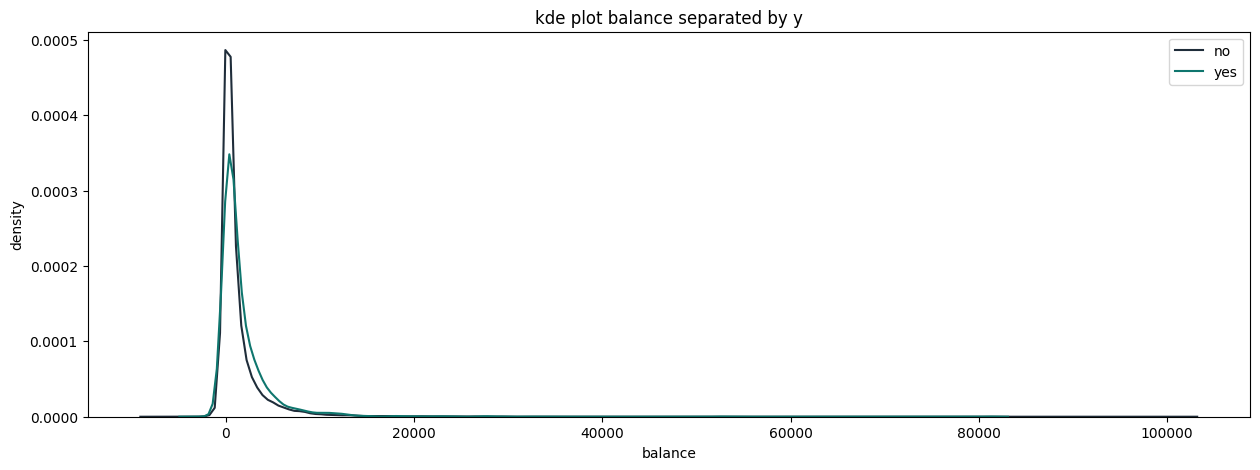

In [120]:
plt.figure(figsize=(15, 5))
sns.kdeplot(df2_no["balance"], label="no", color=palette[0])
sns.kdeplot(df2_yes["balance"], label="yes", color=palette[1])
plt.title("kde plot balance separated by y")
plt.xlabel("balance")
plt.ylabel("density")
plt.legend()
plt.show()

- H0: распределение `balance` у клиентов с `y = yes` и `y = no` не отличается.
- H1: распределение `balance` у клиентов с `y = yes` и `y = no` отличается.

In [121]:
g0 = df2_no["balance"]
g1 = df2_yes["balance"]
stat, p = mannwhitneyu(g0, g1)
print(f"Mean: {g0.mean():.2f} (no), {g1.mean():.2f} (yes)")
print(f"Median: {g0.median():.2f} (no), {g1.median():.2f} (yes)")
print(f"Stat: {stat}, p-value: {p:.6f}")

Mean: 1303.71 (no), 1804.27 (yes)
Median: 417.00 (no), 733.00 (yes)
Stat: 86557474.5, p-value: 0.000000


P Value < 0.05 --> отвергаем HO.

Тест показал статистически значимые различия распределения двух групп. Соответственно, есть статистически значимая связь между балансом клиента и вероятностью открытия им депозита.

In [122]:
df2["balance_level"] = pd.qcut(df2["balance"], q=4, labels=["1", "2", "3", "4"])
df2[["balance", "balance_level"]].head(10)

,balance,balance_level
0,2143,4
1,29,1
2,2,1
3,1506,4
4,1,1
5,231,2
6,447,2
7,2,1
8,121,2
9,593,3


In [123]:
df2["balance_level"].value_counts()

balance_level
1    11317
3    11306
4    11297
2    11291
Name: count, dtype: int64

In [124]:
df2.groupby("balance_level")["y_new"].mean()

/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/1090232642.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("balance_level")["y_new"].mean()


balance_level
1    0.072369
2    0.108936
3    0.125155
4    0.161547
Name: y_new, dtype: float64

Как видим, с ростом уровня доходов процент конверсии повышается. Для того, чтобы доказать это не только интуитивно, но и с точки зрения статистики, проведем chi-square анализ.

In [125]:
grouped = df2.groupby(["balance_level", "y_new"]).size().unstack()
print(grouped)

y_new              0     1
balance_level             
1              10498   819
2              10061  1230
3               9891  1415
4               9472  1825


/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/2229281835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df2.groupby(["balance_level", "y_new"]).size().unstack()


- H0: вероятность открытия депощита не зависит от уровнгя баланса клиента
- H1: вероятность открытия депозита различается между уровнями баланса клиентов

In [126]:
chi2, p, dof, expected = chi2_contingency(grouped)

print(f"p-value: {p:.6f}")

n = grouped.to_numpy().sum()
k = min(grouped.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Cramer: {cramers_v}")

p-value: 0.000000
Cramer: 0.09972603280110669


P Value < 0.05 --> отвергаем H0
Как показал анализ с использованием критерия chi-square, между уровнем баланса клиента и конверсией в открытие депозита существует статистически значимая связь, однако она слабая по Cramer. При этом наблюдается рост конверсии с увеличением уровня баланса клиента. 

/var/folders/89/h99ss5y573q5_6638wn8xp9h0000gn/T/ipykernel_21290/1000152851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df2.groupby("balance_level")["y_new"].mean()


<Axes: xlabel='balance_level'>

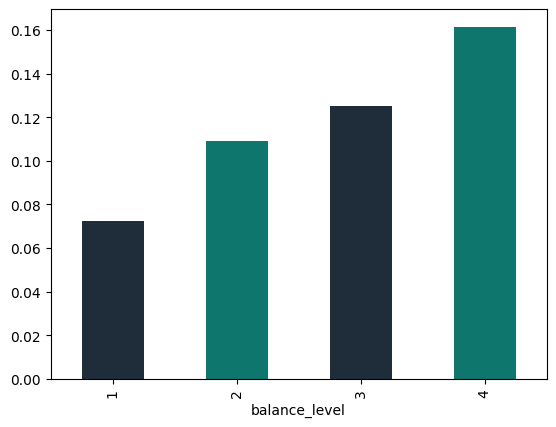

In [127]:
temp = df2.groupby("balance_level")["y_new"].mean()
temp.plot(kind="bar", color=pick_color(temp))

### Гипотеза 3
Наличие кредита на жилье связано с открытием депозита

EDA показал, что клиенты без `housing` имеют более высокую конверсию.
- H0: доля открывших депозит одинакова для `housing = yes` и `housing = no`.
- H1: доли открывших депозит различаются.

In [128]:
df3 = df.copy()
conv = df3.groupby("housing")["y_new"].agg(["count", "mean"])
conv

,count,mean
housing,,
no,20081,0.167024
yes,25130,0.077000


In [129]:
grouped = df3.groupby(["housing", "y_new"]).size().unstack()
chi2, p, dof, expected = chi2_contingency(grouped)

print(f"P-value: {p:.6f}, Chi2: {chi2:.3f}, DOF: {dof}")

n = grouped.to_numpy().sum()
k = min(grouped.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Cramer: {cramers_v}")

P-value: 0.000000, Chi2: 874.822, DOF: 1
Cramer: 0.1391034505051807


P Value < 0.05 -> H0 отвергаем.
Между наличием кредита на жилье и конверсией в откритие депозита есть статистическая связь, но она слабая (0.14 cramer). Дополнительно проведем ztest

In [130]:
a = df3[df3["housing"] == "no"]["y_new"]
b = df3[df3["housing"] == "yes"]["y_new"]

count = [a.sum(), b.sum()]
nobs = [a.count(), b.count()]

stat, p = proportions_ztest(count, nobs)

ci_low, ci_high = confint_proportions_2indep(
    count1=count[0],
    nobs1=nobs[0],
    count2=count[1],
    nobs2=nobs[1],
    method="wald",
    alpha=0.05,
)

print(f"stat: {stat:.6f}, p: {p:.6f}")
print(f"CI: ({ci_low:.6f}, {ci_high:.6f})")

stat: 29.592123, p: 0.000000
CI: (0.083902, 0.096146)


Доверительный интервал z-test показывает, что конверсия у клиентов без housing выше примерно на 8.4-9.6%.

In [131]:
expected_df = pd.DataFrame(expected, index=grouped.index, columns=grouped.columns)
comp_df = pd.concat([grouped, expected_df], axis=1, keys=["observed", "expected"])
comp_df

observed            expected             
y_new          0     1             0            1
housing                                          
no         16727  3354  17731.828139  2349.171861
yes        23195  1935  22190.171861  2939.828139

Text(1, 25500, '0.077')

<Figure size 900x900 with 0 Axes>

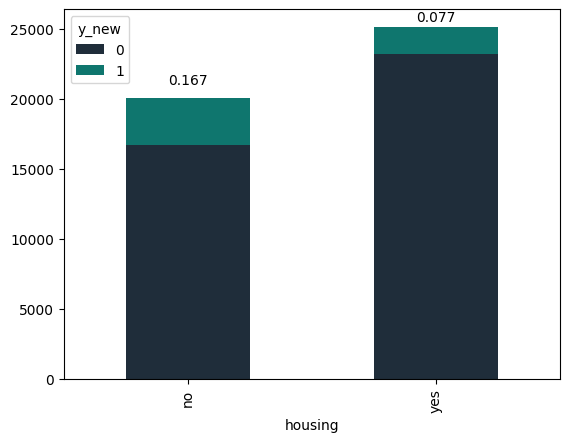

In [132]:
plt.figure(figsize=(9, 9))
grouped.plot(kind="bar", stacked=True, color=palette)
plt.text(0, 21000, f"{conv.iloc[0, 1]:.3f}", ha="center")
plt.text(1, 25500, f"{conv.iloc[1, 1]:.3f}", ha="center")